# Task: Sampling Theorem

**Student Name:**  Sandra Senn

**Country:**  Morocco

**Semester term:** FS26  

**Repository:** https://github.com/Sandra-Senn/gbsv_mc


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile as wav
from scipy import signal
import IPython.display as ipd
from moviepy import VideoFileClip

## Morocco - Dromedar Market


<p style="display: flex; align-items: center ;">
  <span style="flex: 1;">Imagine this: It's Valentine's Day, February 14th, during my semester break. I packed my backpack and embarked on a three-week adventure to Morocco – first exploring the heart of the country, then joining a friend I met there for an unforgettable 5-day road trip through the south. We ended up at the weekly camel and dromedar market in Guelmim, a vibrant chaos of colors, smells, and sounds. Amid the haggling and bleating herds, I captured a short video of a baby dromedar letting out a piercing cry – a moment frozen in time, but buried under camera noise and market bustle.
This 2-second video clip becomes the heart of my 15-Day Mini Challenge 1. </span>
  <img src="data/guelmim.jpeg" style="width:250px; margin-left: 10 px;">
</p>

## Day 1 – Data & Domain

### Use Case
Analyzing the audio track from my Guelmim market video, in the context of animal welfare monitoring, continuous-time acoustic signals generated by a baby dromedar's cry amid noise (wind, chatter, white noise) are acquired and converted into digital form using a camera microphone in order to extract pure vocalization for health/stress insights. 

These digital signals could later be analyzed by veterinarians and researchers to perform non-invasive condition assessments. This use case is particularly relevant for Switzerland because zoos like Basel prioritize ethical, low-cost acoustic monitoring of exotic species, seamlessly linking global travel data like my Morocco recording to local conservation and education.

### Problem Statement

This project addresses the problem of determining an appropriate sampling rate for digitizing the baby dromedar cry within the context of animal welfare monitoring from my Guelmim market video, applied in Swiss zoos like Basel.
If the sampling rate is chosen too low, high-frequency cry harmonics may alias into lower frequencies, leading to distorted timbre that blends with white noise/market disturbances, preventing clean extraction. If the sampling rate is chosen too high, this may result in excessive data volume and processing load, causing unnecessary battery drain and storage issues in field/mobile monitoring.
Preserving spectral fidelity of the cry's bandwidth is essential for reliable health/stress assessment in this non-invasive acoustic analysis.

### Experimental Objective


<div style="display: flex; align-items: center;">
  <video src="data/dromedar.mp4" width="250" style="margin-right: 20px;" controls></video>
  <div style="flex: 1;">
  The objective of this project is to examine how the choice of sampling rate affects the accuracy with which relevant signal features (cry spectrum, harmonics) can be captured in the context of digitizing my Guelmim dromedar cry amid noise for Swiss zoo welfare monitoring.
  The goal is to determine under which sampling conditions the signal remains sufficiently informative for reliable health assessment and noise separation.

  The selected signal represents the acoustic vocalization of a baby dromedary, generated by the animal's laryngeal and vocal-tract anatomy under stress or excitation, recorded using the built-in microphone of a smartphone camera (iPhone), and expressed in normalized amplitude [–1, +1] after 16-bit PCM quantization at 44 100 Hz.

Its relevant characteristics include a clear fundamental frequency of approximately <strong>428 Hz</strong>, a series of odd and even harmonics extending up to roughly <strong>6.3 kHz</strong> (enclosing 99.9 % of total signal energy), and a short transient duration of <strong>~2.4 seconds</strong> – all of which are critical for faithful timbre reconstruction and stress-state classification.

The data originate from a personal field recording made at the weekly dromedary market in <strong>Guelmim, southern Morocco (February 2026)</strong>, and are appropriate because they provide a real, unprocessed acoustic sample of the target species under natural market conditions, directly motivating the sampling-rate analysis within the context of zoo-based animal welfare monitoring at institutions such as Zoo Basel, Switzerland.
  </div>
</div>

In [4]:
# # in order to do our mini challenge in the 1D-Signalspace we have to convert the mp4 to a wav file

with VideoFileClip("data/dromedar.mp4") as video:
    # Extract audio
    audio = video.audio
    # Save as WAV (PCM 16-bit)
    audio.write_audiofile("data/dromedar.wav", codec="pcm_s16le")


MoviePy - Writing audio in data/dromedar.wav


MoviePy - Done.


Sample rate       : 44100 Hz
Duration          : 2.410 s
Total samples     : 106281


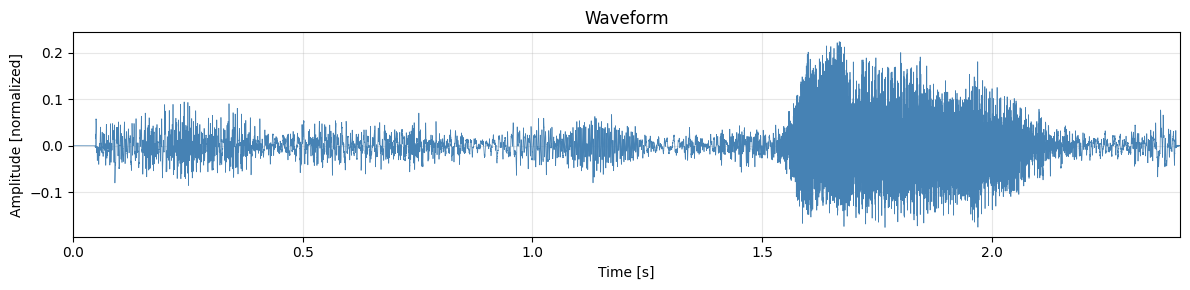

Original recording (44 100 Hz):


In [5]:
# Load audio extracted from the Guelmim market video 
fs, raw = wav.read('../mc1/data/dromedar.wav')
# Mono konvertieren falls Stereo
if raw.ndim == 2:
    raw = raw.mean(axis=1).astype(raw.dtype)

audio = raw.astype(np.float32) / np.iinfo(raw.dtype).max   # normalize to [-1, 1]
t = np.arange(len(audio)) / fs
duration = len(audio) / fs

print(f'Sample rate       : {fs} Hz')
print(f'Duration          : {duration:.3f} s')
print(f'Total samples     : {len(audio)}')

# Nur Waveform anzeigen
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(t, audio, color='steelblue', linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude [normalized]')
ax.set_title('Waveform')
ax.set_xlim([0, t[-1]])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Playback 
print('Original recording (44 100 Hz):')
ipd.display(ipd.Audio(audio, rate=fs))


**Observations**:
The visualization illustrates the normalized waveform of a field recording from the Guelmim camel market, with notable amplitude bursts observed in the segment between approximately 1.5 s and 2.2 s. This region clearly captures the cry of a baby dromedary, characterized by a sharp onset and sustained high-energy oscillation reaching amplitudes of ±0.2. In the earlier segment (0.0 s – 1.5 s), lower-amplitude, irregular fluctuations are visible, corresponding to background crowd noise and human speech. This recording was selected because it clearly highlights the contrast between human vocal activity and animal vocalizations, directly relevant to the investigation of animal sound detection and signal segmentation.

## Day 2 – Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the **Nyquist–Shannon Sampling Theorem** to the digital acquisition of baby dromedary vocalizations within the context of acoustic animal welfare monitoring at Swiss zoos (Zoo Basel).

The theorem states that a continuous, band-limited signal with maximum frequency component f_max can be perfectly reconstructed from its samples if and only if the sampling rate satisfies f_s ≥ 2 · f_max; this minimum rate is called the **Nyquist rate**. 

The theorem's core assumption is **strict band-limitation**: 

all signal energy must be confined below the Nyquist frequency f_N = f_s / 2; if energy exists above f_N, those components alias back into the baseband and become indistinguishable from lower-frequency content. Discrete-time sampling is selected as the operationalization because the microphone ADC pipeline in the recording device performs uniform temporal sampling, making the theorem directly applicable. If the band-limitation assumption is violated (e.g., high-frequency market noise extends beyond f_N), aliased components will corrupt the cry harmonics, preventing reliable stress-state classification in the welfare monitoring application.

### Parameter Definition and Mathematical Specification

**Data-inherent parameters:**

| Parameter | Symbol | Value | Unit | Derivation / Source | Relevance for Use Case |
|:---|:---|:---|:---|:---|:---|
| Original sampling rate | f_s | 44 100 | Hz | iPhone camera ADC |Starting point; maximum available information density |
| Signal duration | T | 2.415 | s | len(samples) / f_s | Determines temporal resolution and total data volume |
| Fundamental frequency | f₀ | 428 | Hz | argmax of \|FFT\| | Fundamental frequency of the dromedary; basis for voice characteristics |
| 99.9 % energy bandwidth | B | 6 345 | Hz | cumulative power spectrum | Effective signal bandwidth; defines which frequencies are relevant |
| Nyquist frequency | f_N | 6 345 | Hz | f_N = B | Highest frequency that can be recorded without loss of information |
| **Nyquist rate (minimum f_s)** | **f_s,min** | **12 690** | **Hz** | **f_s,min = 2 · B** | Theoretical lower limit for lossless digitization |

**Derivation of the Nyquist rate:**

The 99.9 % cumulative-power boundary of the cry spectrum was determined as B = 6 345 Hz. Treating this as the effective maximum frequency of the band-limited signal:

    f_s,min = 2 · f_N = 2 · 6 345 Hz = 12 690 Hz

In this domain, a lag of 1/f_s = 22.7 µs corresponds to the temporal spacing between adjacent microphone samples. The harmonic series H1–H11 (428 Hz … 4 708 Hz) constitutes the perceptually relevant frequency content for timbre and stress-state assessment; all harmonics fall well within the Nyquist band at f_s,min, confirming that 12 690 Hz is a sufficient, physically motivated minimum.*

In [6]:
# ouputs values for the Parameter Definition table

# Original sampling rate
f_s_original = fs
print(f"Original sampling rate (f_s): {f_s_original} Hz")

# Signal duration
T_duration = duration
print(f"Signal duration (T): {T_duration:.3f} s")

freqs  = np.fft.rfftfreq(len(audio), d=1/fs)
spec   = np.abs(np.fft.rfft(audio))

# Fundamental frequency
f_0_fundamental = freqs[np.argmax(spec)]   # fundamental frequenc
print(f"Fundamental frequency (f₀): {f_0_fundamental:.2f} Hz")

# 99.9% energy bandwidth
cumpower = np.cumsum(spec**2)
B_bandwidth = freqs[np.searchsorted(cumpower, 0.999 * cumpower[-1])]
print(f"99.9% energy bandwidth (B): {B_bandwidth:.2f} Hz")

# Nyquist frequency
f_N_nyquist = B_bandwidth
print(f"Nyquist frequency (f_N): {f_N_nyquist:.2f} Hz")

# Nyquist rate (minimum sampling rate = 2 * Nyquist frequency)
f_s_min_nyquist = 2 * f_N_nyquist
print(f"Nyquist rate (f_s,min): {f_s_min_nyquist:.2f} Hz")

Original sampling rate (f_s): 44100 Hz
Signal duration (T): 2.410 s
Fundamental frequency (f₀): 428.63 Hz
99.9% energy bandwidth (B): 6346.89 Hz
Nyquist frequency (f_N): 6346.89 Hz
Nyquist rate (f_s,min): 12693.78 Hz


### Experimental Design for Next Days

The **baseline configuration** is defined as uniform sampling of the 44 100 Hz reference signal at **f_s = 16 000 Hz** (well above Nyquist), which should faithfully preserve all harmonics up to 8 000 Hz.

The following **four sampling rates** will be varied systematically in Day 3:

| Configuration | f_s [Hz] | Relation to Nyquist rate | Expected behavior |
|:---|:---|:---|:---|
| Above Nyquist (baseline) | 16 000 | 1.26 × f_s,min | No aliasing; all harmonics preserved |
| At Nyquist rate | 12 690 | 1.00 × f_s,min | Marginal; boundary harmonics may lose phase accuracy |
| Below Nyquist (moderate) | 8 000 | 0.63 × f_s,min | Harmonics above 4 kHz alias into base band |
| Below Nyquist (severe) | 4 000 | 0.32 × f_s,min | Severe aliasing; only H1–H4 representable |

The range spans from 4 × below to 1.26 × above the Nyquist rate to expose the full spectrum from clean reconstruction to severe distortion. It is theoretically expected that decreasing f_s below f_s,min will progressively fold upper harmonics back into the fundamental region, inflating low-frequency energy and distorting the harmonic ratios that encode stress-related timbre information. All configurations will be implemented by downsampling the 44 100 Hz reference and are fully documented to ensure traceability.

### Methodological Limitations and Risk Factors
This approach assumes that the dromedary cry is **strictly band-limited** below 6 345 Hz, which may be violated because broadband market noise (wind, crowd chatter) overlaps the entire audible spectrum, meaning that some aliased energy in undersampled conditions originates from noise rather than vocalization harmonics – potentially overstating cry distortion.

The method is expected to be reliable when the recording environment is relatively quiet and the cry's signal-to-noise ratio is high, but may become misleading when market noise energy above the Nyquist frequency is aliased and interpreted as cry content, confounding the welfare classification.

In this use case, the primary risk factors are 

**(1)** the non-stationary nature of the cry (amplitude and pitch vary over the 2.4 s clip) violating the stationarity implied by a single global bandwidth estimate, and 

**(2)** the absence of an anti-aliasing low-pass filter in the downsampling simulation (a real ADC would include one), meaning the measured aliasing in Day 3 represents a worst-case scenario that overestimates field-deployment distortion.


## Day 3 – Implementation

*Focus: structured, traceable execution*

<span style="background-color: #eeeeee;">*Guidelines: Implement the previously defined methodological framework in a structured and reproducible manner. Organize your notebook clearly, separating data preparation, parameter definition, baseline configuration, and parameter variation. The implementation must directly follow the previously defined methodological plan. All relevant parameters must be explicitly declared and applied as specified. Do not introduce new methods or undocumented parameter changes; any deviation must be briefly justified (one sentence).
Ensure that each experiment is traceable by clearly labeling configurations and avoiding undocumented changes. Visualizations must include properly labeled axes (with units where applicable), clear legends, and consistent formatting to allow comparison across parameter settings.
 If not otherwise stated, libarys may be used for your implementations. Keep experiments concise and focused. Observations, interpretation and performance evaluation will be conducted on a later day.*</span>

<span style="background-color: #eeeeee;">*Code Quality Requirements: The submission must not contain any commented-out code passages. Code should be clean, readable, and executable without residual development artifacts. Comments should be used sparingly and only where they add value. In particular, comments are appropriate when explaining why a specific methodological decision was made, clarifying non-obvious implementation details, or referencing a theoretical source. Avoid redundant comments that merely restate what the code already expresses.
The code should be written in a clear and structured manner such that its logic is largely self-explanatory. Use meaningful variable names and consistent formatting to enhance readability.*</span>

## Day [4, 9, 14] – Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

<span style="background-color: #eeeeee;">*Systematically evaluate the predefined experiment design in relation to the defined use case. The evaluation must be traceable, structured, and based on consistent criteria. All reported metrics or extracted quantities must include appropriate physical units or clearly indicate normalization to ensure consistent and meaningful comparison. The same predefined evaluation approach must be applied consistently across all experiments and parameter configurations to maintain traceability and comparability.No new simulations, theoretical derivations, or interpretative discussion should be introduced.*</span>

### Evaluation Approach Definition

<span style="background-color: #eeeeee;">*Guidelines: Define 1–2 quantitative evaluation approaches, which may consist of numerical metrics and/or quantitatively interpretable visualizations. Justify why the selected approach is appropriate for your signal or image characteristics and application objective, and clearly specify what aspect of performance it captures (e.g., fidelity, detection accuracy, reconstruction quality, robustness, distortion). Visualizations must include labeled axes with units and enable measurable comparison across configurations. 2-3 sentences.*</span>

You may use the following structures as guidance, depending on whether your evaluation approach is metric-based or visualization-based.

#### Template – Metric-Based Evaluation

> The selected metric is __________, which quantifies ____________ in relation to [the defined use case].
It is specifically chosen because the problem statement requires accurate assessment of ____________, and this metric directly reflects changes in ____________.
The validity of this metric depends on ____________, which must hold for the evaluation to be meaningful in this application.

Example – Root Mean Squared Error (RMSE):

> The selected metric is RMSE, which quantifies the deviation between the reconstructed signal and the high-resolution reference. It is specifically chosen because [the use case] requires accurate amplitude reconstruction over time, and RMSE directly reflects reconstruction fidelity. The metric is meaningful here because a validated reference signal is available and serves as ground truth.

#### Template – Visualization-Based Evaluation

> The evaluation uses a __________ visualization, representing ____________ with clearly labeled axes and units.
The evaluated quantity is ____________, which is directly relevant to [the defined use case] because the problem requires reliable assessment of ____________.
This approach is appropriate under ____________, ensuring that the extracted feature meaningfully reflects performance in this application context.

Example – Frequency Spectrum Comparison:

> The evaluation uses a frequency spectrum visualization to assess whether dominant periodic components are preserved. The evaluated quantity is the measurable peak frequency and its amplitude, which are directly relevant because the use case requires reliable detection of periodic behavior. This approach is appropriate since frequency preservation is more critical than pointwise amplitude accuracy in this application.

### Evaluation Comparison Execution

<span style="background-color: #eeeeee;">*Guidelines: Apply the defined evaluation approach consistently across all predefined experiments or configurations. Systematically vary 2–4 previously defined key parameters and quantify their influence on performance relative to a clearly specified baseline configuration. Results must be reported in a structured format (e.g., tables or measurable graphics) to ensure traceability. 2-4 sentences.*</span>


#### Template – Parameter Evaluation (Metric-Based)

>The influence of key parameters __________ was evaluated using the previously defined metric __________.
These parameters are essential for [the defined use case] because they directly affect ____________, which is critical for ____________.
Changes in __________ [metric] across parameter settings quantify how sensitive the experiment design is to ____________.
Relative performance change was computed with respect to the baseline configuration ____________.

#### Template – Parameter Evaluation (Visualization-Based)

>The influence of key parameters __________ was evaluated using the previously defined visualization-based measure __________.
These parameters are essential for the defined use case because they influence ____________, which determines ____________ in [the application context].
Differences in the extracted quantity __________ across parameter settings quantify the impact of ____________ on performance.
Relative performance change was computed with respect to the baseline configuration ____________.

In [7]:
## Placeholder for code-based analysis, quantitative result reporting, and structured comparison using tables and/or graphics.

Example universal comparison table:

| Experiment / Configuration        | Metric / Quantity 1 | Metric / Quantity 2 (optional) | Relative Change to Baseline (%) |
|:----------------------------------|:--------------------|:--------------------------------|:--------------------------------|
| Baseline: ____________            |                     |                                  | 0%                               |
| Configuration 1: ____________     |                     |                                  |                                  |
| Configuration 2: ____________     |                     |                                  |                                  |
| Configuration 3: ____________     |                     |                                  |                                  |


Example for Sampling Rate Variation:


| Experiment / Configuration | RMSE | Relative Change to Baseline (%) |
|:----------------------------|:-----|:--------------------------------|
| Baseline: Fs = 100 Hz      | 0.12 | 0%                               |
| Fs = 50 Hz                 | 0.18 | +50%                             |
| Fs = 25 Hz                 | 0.45 | +275%                            |

## Day [5, 10, 15] – Analysis & Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image. Structure your analysis into (1) observations, (2) interpretation, and (3) discussion. Observations must reference concrete quantitative results; interpretations must explain domain-specific implications; the discussion must critically assess the practical applicability, limitations, and risks of your implementation and evaluation approach. All arguments must explicitly connect to the original problem statement and use case. No new simulations or derivations may be introduced.*</span>

### Observations (3-5 sentences)
Focus: Describe measurable results only — no explanation.

> The quantitative evaluation shows that ____________ changes from ____________ to ____________ across configurations ____________.
The defined metric / extracted quantity indicates that ____________.
Performance differences are most pronounced when ____________.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.

>In the context of ____________ [use case], these results imply that ____________.
The observed variation in ____________ affects ____________ because ____________.
This suggests that ____________ is particularly critical for achieving the objective defined in the problem statement.


### Discussion and Critical Reflection (4–6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*

> For the defined use case, the configurations ____________ performed well because they achieved ____________, which aligns with the requirement of ____________.
In contrast, configurations ____________ showed reduced performance, leading to ____________ and limiting their suitability for this application.
The achieved performance level can be considered sufficient / insufficient for the use case because ____________.
The implementation and evaluation approach assumes ____________, which may be constrained under real-world conditions such as ____________.
To improve robustness or applicability, future work should address ____________ or refine ____________.

## Day 15 

### Final Reflections on MC
>Overall, the most successful aspect of MC1 was ____________, particularly in relation to ____________ within the defined use case. The implementation of ____________ worked well because ____________, leading to ____________.
If repeating this work, I would reconsider ____________ or refine ____________, as this could improve ____________ and reduce ____________. Certain challenges emerged during ____________, highlighting the importance of ____________ in practical signal/image analysis.
I was particularly impressed by ____________, especially how ____________ influenced ____________ in the context of the application.
Through this project, I learned that ____________, and I developed a clearer understanding of ____________, especially regarding the connection between theoretical principles and real-world constraints.

### Revisions
<span style="background-color: #fff3b0;"><strong>Template for Revisions:</strong> [your changes... ]</span>